# 14 -- PAE K=5 Full Analysis: VIM-Filtered Breast CyTOF

Full biological analysis with complete clinical annotation from BreastMS_tables.xlsx.

**Model:** `outputs/breast_pae_novim_k_sweep/runs/probabilistic_archetypal_ae/dim_05/seed_123`  
**Report:** `reports/k5_novim_pae/`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

REPO_ROOT = Path('../../')
RUN_DIR   = REPO_ROOT / 'outputs/breast_pae_novim_k_sweep/runs/probabilistic_archetypal_ae/dim_05/seed_123'
H5AD_PATH = REPO_ROOT / 'data/breast_cytof_novim_processed.h5ad'
OUT_DIR   = REPO_ROOT / 'reports/k5_novim_pae'
FIG_DIR   = OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

COMP_NAMES = [
    'A0: Luminal progenitor',
    'A1: Mature luminal A',
    'A2: Basal/myoepithelial',
    'A3: EZH2-high aggressive',
    'A4: Luminal B (bivalent)',
]
K = len(COMP_NAMES)
W_COLS = [f'w_{i}' for i in range(K)]

# Clinical metadata from BreastMS_tables.xlsx Table S2
CLINICAL = {
    '4':   {'subtype':'LUM A','grade':2,'ki67':0.30,'er':0.91,'tumor_type':'IDC','age':61,'note':''},
    '4.1': {'subtype':'LUM A','grade':2,'ki67':0.30,'er':0.91,'tumor_type':'IDC','age':61,'note':'replicate'},
    '5':   {'subtype':'LUM A','grade':2,'ki67':0.30,'er':0.96,'tumor_type':'IDC','age':87,'note':'elderly'},
    '7':   {'subtype':'LUM B','grade':3,'ki67':0.40,'er':0.86,'tumor_type':'IDC','age':37,'note':'young (37y)'},
    '7.1': {'subtype':'LUM B','grade':3,'ki67':0.40,'er':0.86,'tumor_type':'IDC','age':37,'note':'replicate'},
    '8':   {'subtype':'LUM A','grade':2,'ki67':0.10,'er':0.93,'tumor_type':'ILC','age':46,'note':'CDH1 Y523*'},
    '8.1': {'subtype':'LUM A','grade':2,'ki67':0.10,'er':0.93,'tumor_type':'ILC','age':46,'note':'replicate'},
    '11':  {'subtype':'TN',   'grade':3,'ki67':0.90,'er':0.05,'tumor_type':'IDC','age':76,'note':'TP53 c.375+1delG'},
    '13':  {'subtype':'LUM B','grade':3,'ki67':0.50,'er':0.77,'tumor_type':'IDC','age':73,'note':'BRCA1; 47% basal'},
    '14':  {'subtype':'LUM B','grade':3,'ki67':0.50,'er':0.85,'tumor_type':'IDC','age':64,'note':'TP53; 53% basal'},
    '15':  {'subtype':'LUM A','grade':2,'ki67':0.25,'er':0.87,'tumor_type':'IDC','age':63,'note':'PIK3CA E545K'},
    '17':  {'subtype':'LUM B','grade':3,'ki67':0.80,'er':0.73,'tumor_type':'IDC','age':62,'note':'TP53+PIK3CA'},
    '18':  {'subtype':'LUM A','grade':2,'ki67':0.40,'er':0.93,'tumor_type':'IDC','age':67,'note':''},
    '19':  {'subtype':'LUM A','grade':2,'ki67':0.20,'er':0.76,'tumor_type':'IDC','age':44,'note':'PIK3CA H1047R'},
    '20':  {'subtype':'LUM A','grade':2,'ki67':0.20,'er':0.90,'tumor_type':'IDC','age':69,'note':'PIK3CA H1047R'},
}
SUBTYPE_COLORS = {'LUM A':'#4393c3','LUM B':'#d6604d','TN':'#111111','ILC':'#74c476'}

matplotlib.rcParams.update({
    'font.family':'sans-serif','font.size':10,
    'axes.titlesize':11,'axes.labelsize':10,
    'xtick.labelsize':9,'ytick.labelsize':9,
    'figure.dpi':150,'savefig.dpi':200,'savefig.bbox':'tight',
})
ARCHETYPE_COLORS = sns.color_palette('tab10', K)
print('Setup complete. OUT_DIR:', OUT_DIR)


Setup complete. OUT_DIR: ../../reports/k5_novim_pae


In [2]:
import anndata as ad

adata = ad.read_h5ad(H5AD_PATH)
print(f'h5ad: {adata.shape[0]:,} cells x {adata.shape[1]} markers')

cm = pd.read_csv(RUN_DIR / 'component_means.csv', index_col=0)
cv = pd.read_csv(RUN_DIR / 'component_vars.csv', index_col=0)
cm.index = COMP_NAMES; cv.index = COMP_NAMES
MARKERS = list(cm.columns)

hist = pd.read_csv(RUN_DIR / 'training_history.csv')
print(f'Training: {len(hist)} epochs  best val_loss={hist["val_loss"].min():.4f} '
      f'at epoch {int(hist["val_loss"].idxmin())}')

dfs = []
for split in ['train', 'val', 'test']:
    wf = RUN_DIR / split / 'weights.csv'
    if wf.exists():
        df = pd.read_csv(wf, index_col=0)
        df['split'] = split
        dfs.append(df)
all_w = pd.concat(dfs).join(adata.obs[['sample_id']])
all_w['dominant'] = all_w[W_COLS].values.argmax(axis=1)
print(f'Weights: {len(all_w):,} total, {all_w["sample_id"].notna().sum():,} matched')

per_sample_mean = all_w.groupby('sample_id', observed=True)[W_COLS].mean()
per_sample_mean.columns = COMP_NAMES

per_sample_dom = (all_w.groupby('sample_id', observed=True)['dominant']
                  .value_counts(normalize=True).unstack(fill_value=0))
per_sample_dom.columns = [COMP_NAMES[c] for c in per_sample_dom.columns]

sample_counts = adata.obs['sample_id'].value_counts()
sample_order  = sorted(per_sample_mean.index, key=lambda x: float(x))

print('\nCells per sample (post-VIM):')
for s in sample_order:
    c = CLINICAL.get(str(s), {})
    print(f"  S{s}: {sample_counts.get(s,0):>6,}  "
          f"{c.get('subtype','?'):<7} G{c.get('grade','?')}  "
          f"Ki67={c.get('ki67',0):.0%}  ER={c.get('er',0):.0%}  "
          f"{c.get('note','')}")


h5ad: 142,189 cells x 31 markers
Training: 579 epochs  best val_loss=26.5361 at epoch 563
Weights: 142,189 total, 42,658 matched

Cells per sample (post-VIM):
  S4: 10,000  LUM A   G2  Ki67=30%  ER=91%  
  S4.1: 10,000  LUM A   G2  Ki67=30%  ER=91%  replicate
  S5: 10,000  LUM A   G2  Ki67=30%  ER=96%  elderly
  S7: 10,000  LUM B   G3  Ki67=40%  ER=86%  young (37y)
  S7.1: 10,000  LUM B   G3  Ki67=40%  ER=86%  replicate
  S8: 10,000  LUM A   G2  Ki67=10%  ER=93%  CDH1 Y523*
  S8.1: 10,000  LUM A   G2  Ki67=10%  ER=93%  replicate
  S11:  2,189  TN      G3  Ki67=90%  ER=5%  TP53 c.375+1delG
  S13: 10,000  LUM B   G3  Ki67=50%  ER=77%  BRCA1; 47% basal
  S14: 10,000  LUM B   G3  Ki67=50%  ER=85%  TP53; 53% basal
  S15: 10,000  LUM A   G2  Ki67=25%  ER=87%  PIK3CA E545K
  S17: 10,000  LUM B   G3  Ki67=80%  ER=73%  TP53+PIK3CA
  S18: 10,000  LUM A   G2  Ki67=40%  ER=93%  
  S19: 10,000  LUM A   G2  Ki67=20%  ER=76%  PIK3CA H1047R
  S20: 10,000  LUM A   G2  Ki67=20%  ER=90%  PIK3CA H1047R


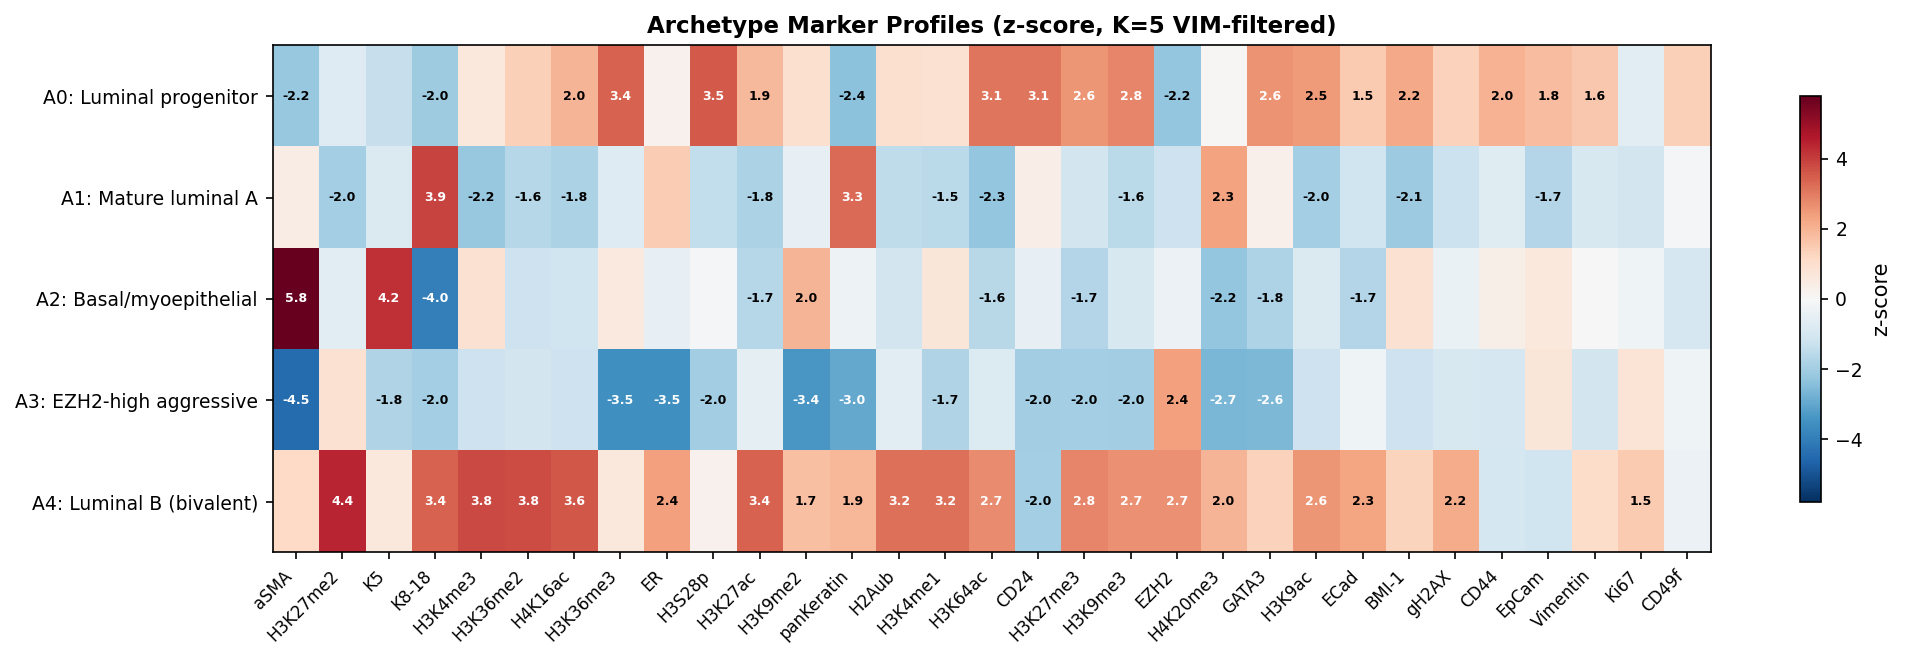

Saved fig1


In [3]:
# Figure 1: Archetype marker profiles heatmap
fig, ax = plt.subplots(figsize=(14, 4.5))
marker_order = cm.abs().max(axis=0).sort_values(ascending=False).index.tolist()
cm_ord = cm[marker_order]
vmax = max(abs(cm.values.min()), abs(cm.values.max()))
im = ax.imshow(cm_ord.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(marker_order)))
ax.set_xticklabels(marker_order, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(K)); ax.set_yticklabels(COMP_NAMES, fontsize=9)
ax.set_title('Archetype Marker Profiles (z-score, K=5 VIM-filtered)', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='z-score', shrink=0.8)
for i in range(K):
    for j, m in enumerate(marker_order):
        val = cm_ord.iloc[i, j]
        if abs(val) > 1.5:
            color = 'white' if abs(val) > 2.5 else 'black'
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=6, color=color, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig1_archetype_heatmap.png')
fig.savefig(FIG_DIR / 'fig1_archetype_heatmap.pdf')
plt.show(); print('Saved fig1')

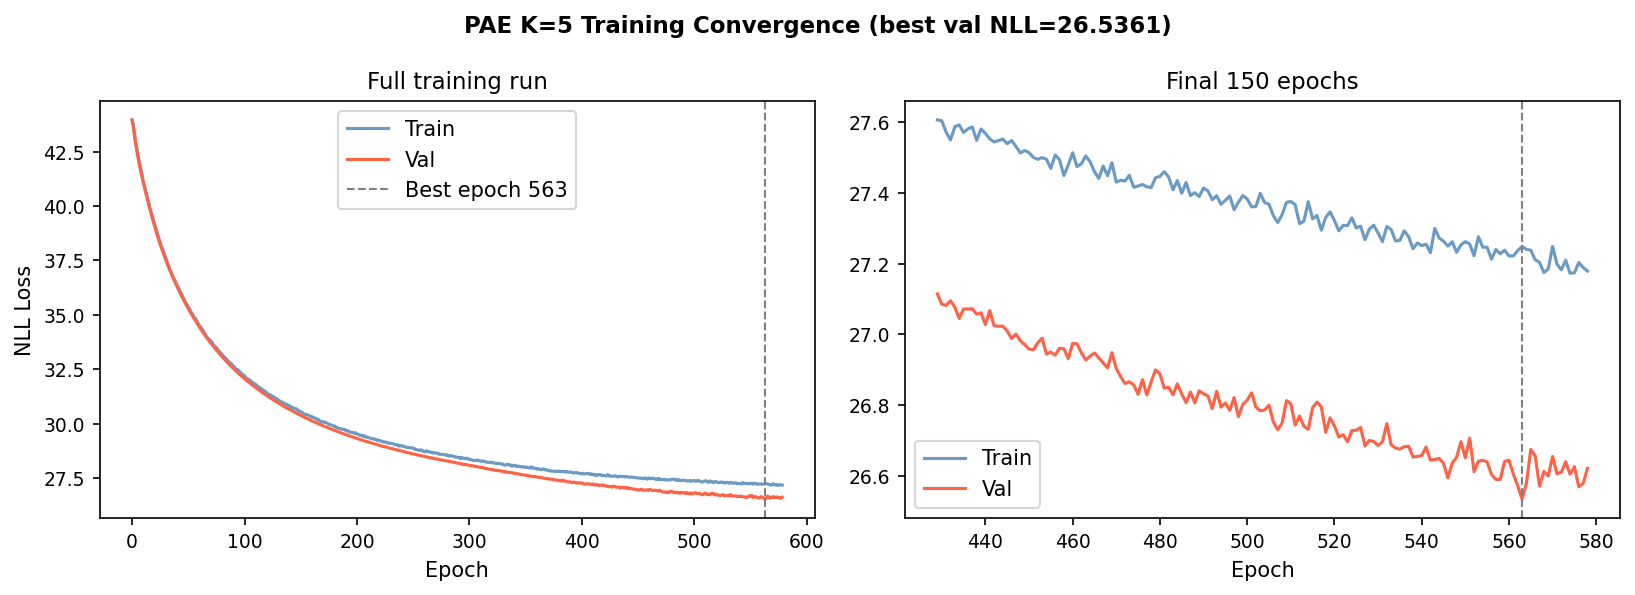

Saved fig2


In [4]:
# Figure 2: Training convergence
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
best_epoch = int(hist['val_loss'].idxmin())
axes[0].plot(hist.index, hist['train_loss'], label='Train', color='steelblue', lw=1.5, alpha=0.8)
axes[0].plot(hist.index, hist['val_loss'], label='Val', color='tomato', lw=1.5)
axes[0].axvline(best_epoch, color='gray', ls='--', lw=1, label=f'Best epoch {best_epoch}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('NLL Loss'); axes[0].set_title('Full training run'); axes[0].legend()
tail = hist.tail(150)
axes[1].plot(tail.index, tail['train_loss'], color='steelblue', lw=1.5, alpha=0.8, label='Train')
axes[1].plot(tail.index, tail['val_loss'], color='tomato', lw=1.5, label='Val')
axes[1].axvline(best_epoch, color='gray', ls='--', lw=1); axes[1].set_xlabel('Epoch')
axes[1].set_title('Final 150 epochs'); axes[1].legend()
fig.suptitle(f'PAE K=5 Training Convergence (best val NLL={hist["val_loss"].min():.4f})', fontsize=11, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig2_training_convergence.png'); fig.savefig(FIG_DIR / 'fig2_training_convergence.pdf')
plt.show(); print('Saved fig2')

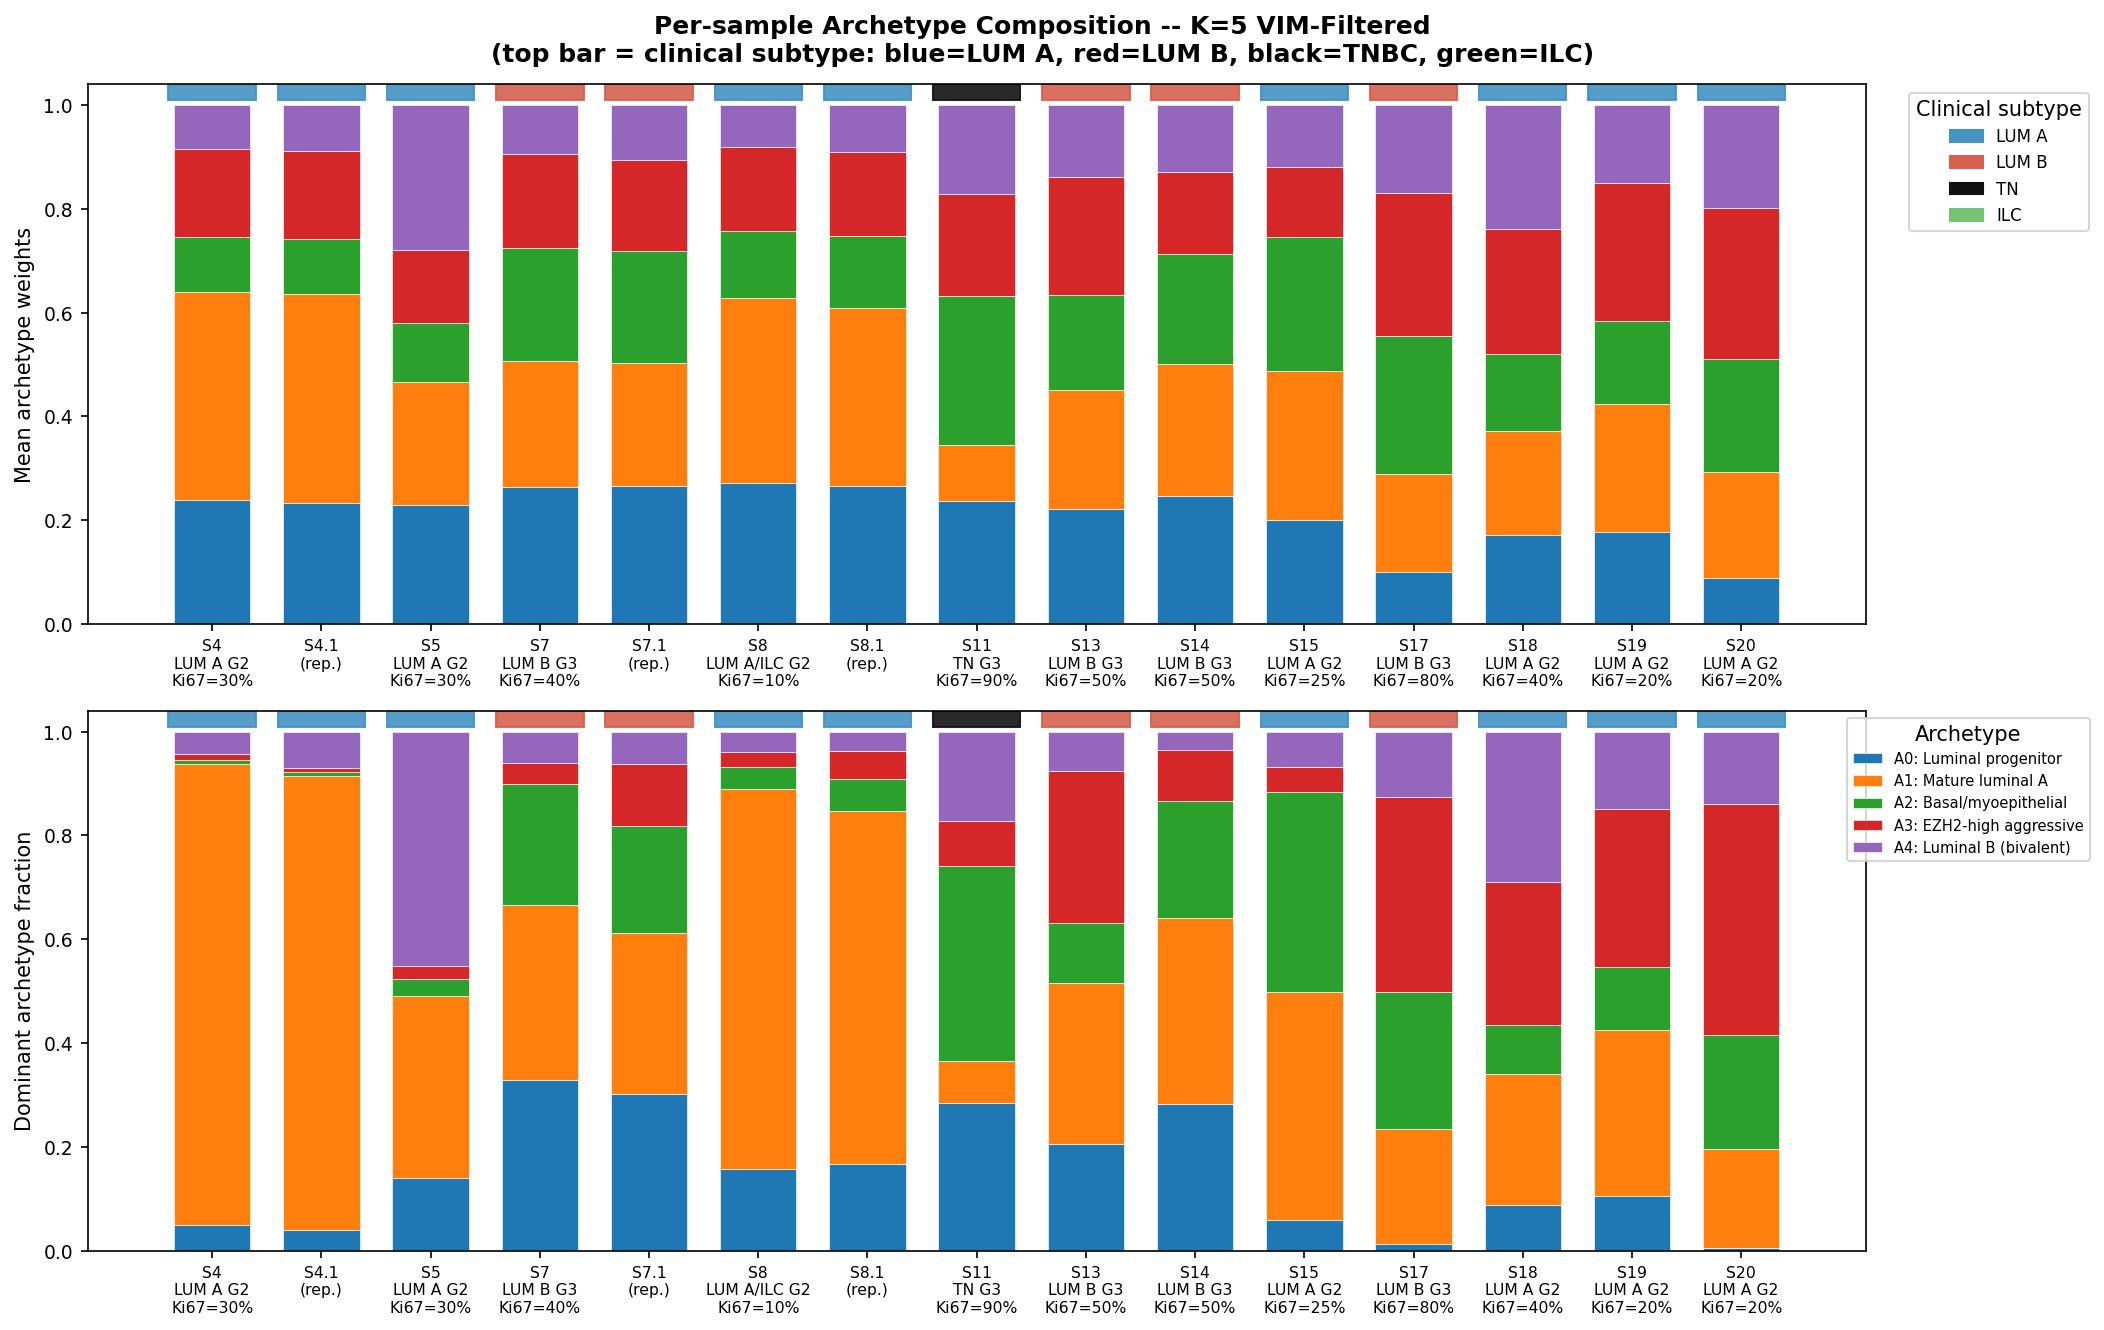

Saved fig3


In [5]:
# Figure 3: Per-sample composition with clinical annotation
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
psmean = per_sample_mean.loc[sample_order]
psdom  = per_sample_dom.reindex(sample_order)
x = np.arange(len(sample_order))

def make_xlabels(order):
    labels = []
    for sid in order:
        c = CLINICAL.get(str(sid), {})
        sub = c.get('subtype','?'); tt = c.get('tumor_type','IDC')
        g = c.get('grade','?'); ki = c.get('ki67',0)
        note = c.get('note','')
        lbl = f'S{sid}\n{sub}'
        if tt == 'ILC': lbl += '/ILC'
        lbl += f' G{g}\nKi67={ki:.0%}'
        if 'replicate' in note: lbl = f'S{sid}\n(rep.)'
        labels.append(lbl)
    return labels

xlabels = make_xlabels(sample_order)
bar_top_colors = [SUBTYPE_COLORS.get(CLINICAL.get(str(s),{}).get('subtype','?'),'gray')
                  for s in sample_order]

for ax_i, (data, title) in enumerate([
    (psmean, 'Mean archetype weights'),
    (psdom,  'Dominant archetype fraction')
]):
    ax = axes[ax_i]
    bottom = np.zeros(len(sample_order))
    for comp, color in zip(COMP_NAMES, ARCHETYPE_COLORS):
        vals = data[comp].fillna(0).values if comp in data.columns else np.zeros(len(sample_order))
        ax.bar(x, vals, bottom=bottom, color=color, label=comp, width=0.7,
               edgecolor='white', linewidth=0.3)
        bottom += vals
    for xi, col in enumerate(bar_top_colors):
        ax.axvspan(xi-0.4, xi+0.4, ymin=0.97, ymax=1.0, color=col, alpha=0.9)
    ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=7.5)
    ax.set_ylim(0, 1.04); ax.set_ylabel(title)
    if ax_i == 1:
        ax.legend(loc='upper right', fontsize=7, bbox_to_anchor=(1.13, 1.0), title='Archetype')

from matplotlib.patches import Patch
legend_subtypes = [Patch(color=v, label=k) for k, v in SUBTYPE_COLORS.items()]
axes[0].legend(handles=legend_subtypes, loc='upper right', fontsize=8,
               bbox_to_anchor=(1.13, 1.0), title='Clinical subtype')
fig.suptitle('Per-sample Archetype Composition -- K=5 VIM-Filtered\n'
             '(top bar = clinical subtype: blue=LUM A, red=LUM B, black=TNBC, green=ILC)',
             fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig3_sample_composition.png')
fig.savefig(FIG_DIR / 'fig3_sample_composition.pdf')
plt.show(); print('Saved fig3')


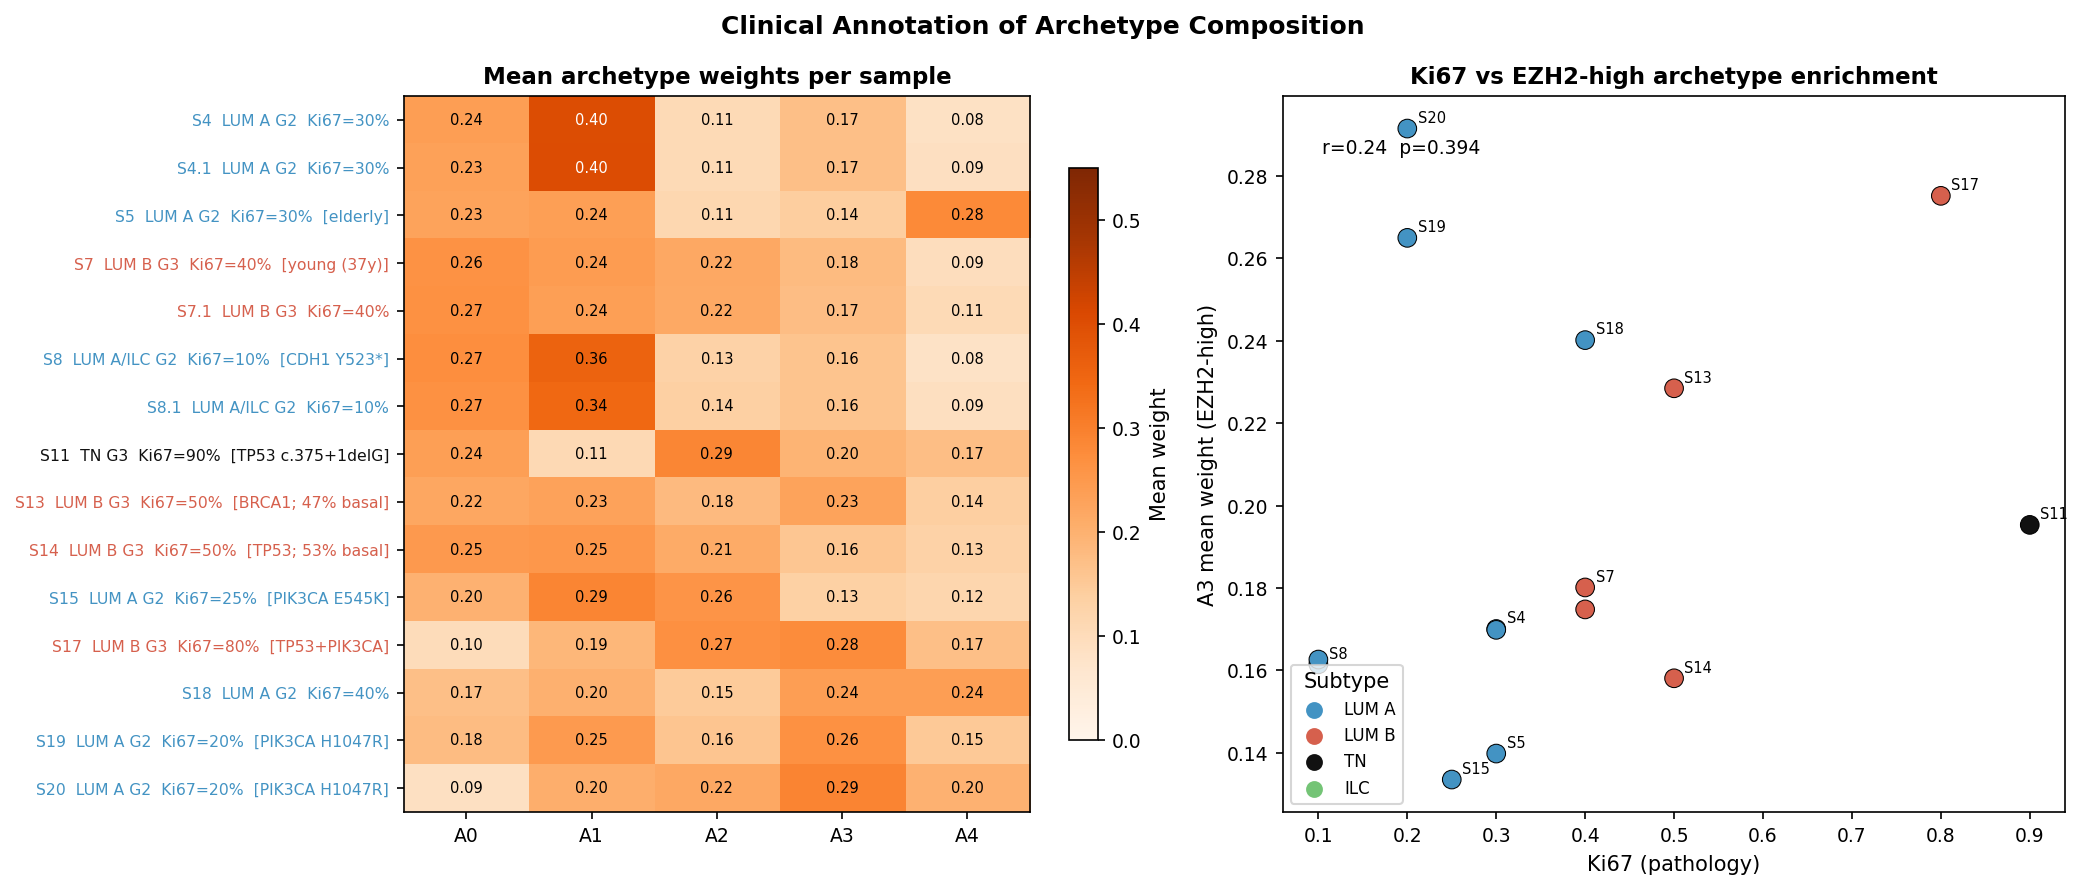

Saved fig4


In [6]:
# Figure 4: Clinical heatmap + Ki67 vs A3 scatter
from scipy.stats import pearsonr
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

psmean_ord = per_sample_mean.loc[sample_order]
im = axes[0].imshow(psmean_ord.values, aspect='auto', cmap='Oranges', vmin=0, vmax=0.55)
axes[0].set_xticks(range(K))
axes[0].set_xticklabels([f'A{i}' for i in range(K)], fontsize=9)
ylabels = []
for sid in sample_order:
    c = CLINICAL.get(str(sid), {})
    sub = c.get('subtype','?'); g = c.get('grade','?'); ki = c.get('ki67',0)
    tt = c.get('tumor_type','IDC'); note = c.get('note','')
    lbl = f"S{sid}  {sub}"
    if tt == 'ILC': lbl += '/ILC'
    lbl += f" G{g}  Ki67={ki:.0%}"
    if note and 'replicate' not in note: lbl += f"  [{note}]"
    ylabels.append(lbl)
axes[0].set_yticks(range(len(sample_order)))
axes[0].set_yticklabels(ylabels, fontsize=7.5)
plt.colorbar(im, ax=axes[0], label='Mean weight', shrink=0.8)
for i, sid in enumerate(sample_order):
    for j in range(K):
        v = psmean_ord.iloc[i, j]
        axes[0].text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                     color='white' if v > 0.38 else 'black')
for tick, sid in zip(axes[0].get_yticklabels(), sample_order):
    col = SUBTYPE_COLORS.get(CLINICAL.get(str(sid),{}).get('subtype','?'),'black')
    tick.set_color(col)
axes[0].set_title('Mean archetype weights per sample', fontweight='bold')

ki67_vals = [CLINICAL.get(str(s),{}).get('ki67',0) for s in sample_order]
a3_vals   = [psmean_ord.loc[s,'A3: EZH2-high aggressive'] for s in sample_order]
colors    = [SUBTYPE_COLORS.get(CLINICAL.get(str(s),{}).get('subtype','?'),'gray') for s in sample_order]
axes[1].scatter(ki67_vals, a3_vals, c=colors, s=80, edgecolors='black', linewidths=0.5, zorder=5)
for xi, yi, sid in zip(ki67_vals, a3_vals, sample_order):
    if 'replicate' in CLINICAL.get(str(sid),{}).get('note',''): continue
    axes[1].annotate(f'S{sid}', (xi, yi), textcoords='offset points', xytext=(5,3), fontsize=7)
axes[1].set_xlabel('Ki67 (pathology)'); axes[1].set_ylabel('A3 mean weight (EZH2-high)')
axes[1].set_title('Ki67 vs EZH2-high archetype enrichment', fontweight='bold')
legend_els = [plt.scatter([],[],c=v,s=50,label=k) for k,v in SUBTYPE_COLORS.items()]
axes[1].legend(handles=legend_els, title='Subtype', fontsize=8)
r, p = pearsonr(ki67_vals, a3_vals)
axes[1].text(0.05, 0.92, f'r={r:.2f}  p={p:.3f}', transform=axes[1].transAxes, fontsize=9)
fig.suptitle('Clinical Annotation of Archetype Composition', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig4_clinical_heatmap.png')
fig.savefig(FIG_DIR / 'fig4_clinical_heatmap.pdf')
plt.show(); print('Saved fig4')


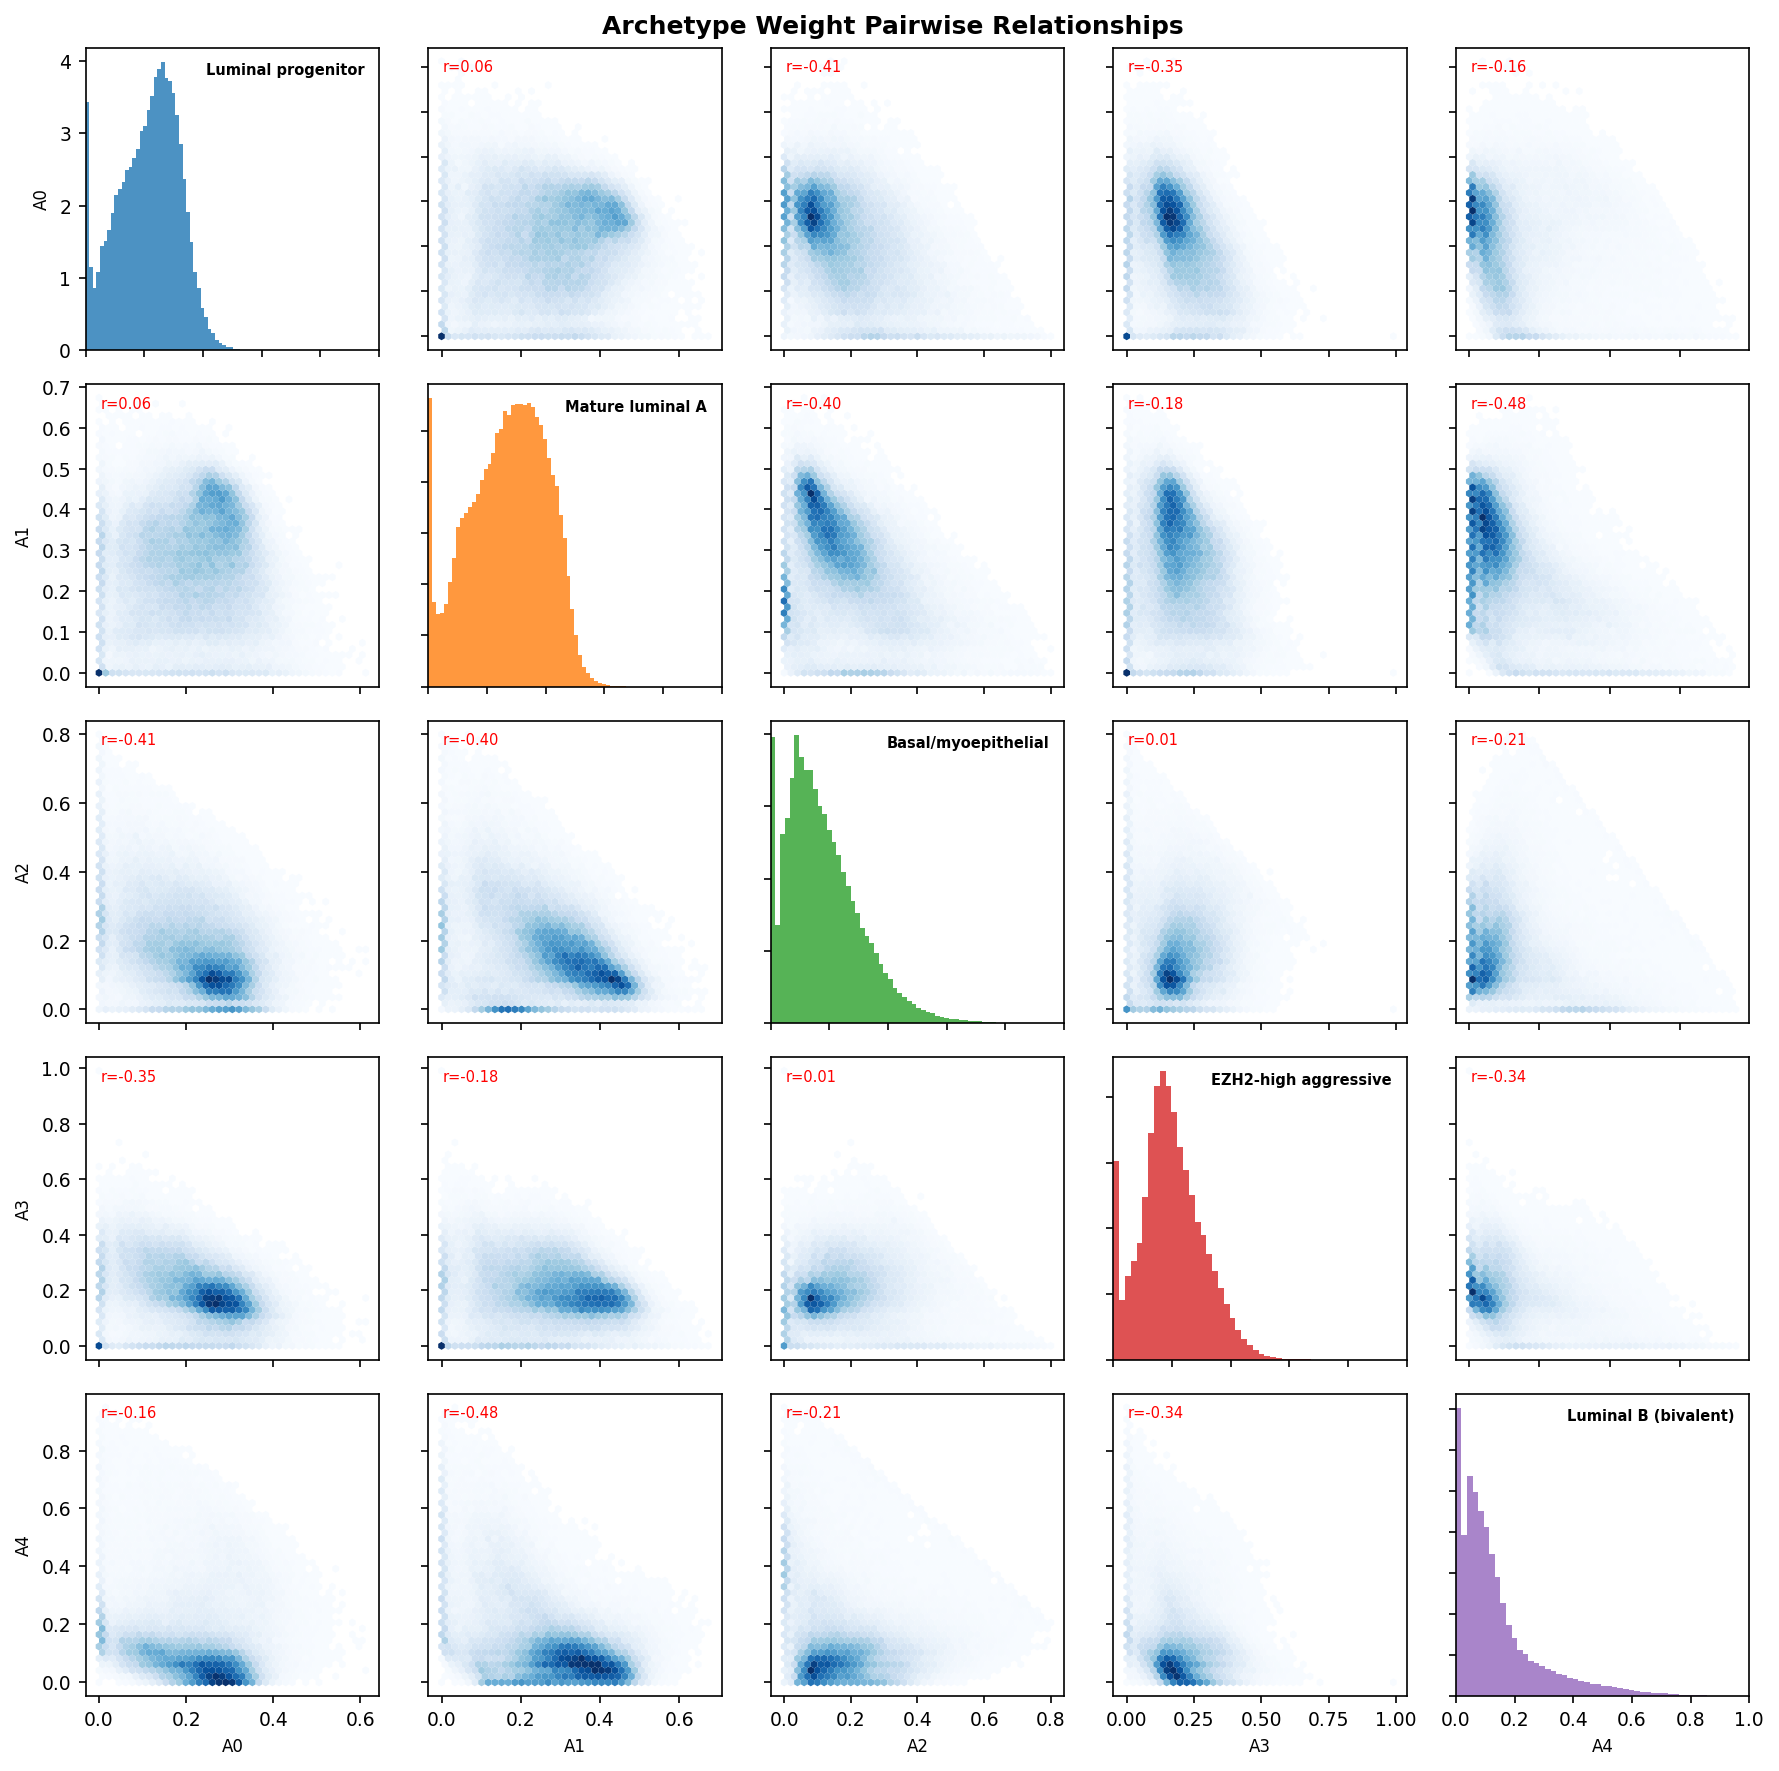

                          A0: Luminal progenitor  A1: Mature luminal A  A2: Basal/myoepithelial  A3: EZH2-high aggressive  A4: Luminal B (bivalent)
A0: Luminal progenitor                     1.000                 0.061                   -0.413                    -0.348                    -0.161
A1: Mature luminal A                       0.061                 1.000                   -0.405                    -0.175                    -0.479
A2: Basal/myoepithelial                   -0.413                -0.405                    1.000                     0.011                    -0.215
A3: EZH2-high aggressive                  -0.348                -0.175                    0.011                     1.000                    -0.340
A4: Luminal B (bivalent)                  -0.161                -0.479                   -0.215                    -0.340                     1.000


In [7]:
# Figure 5: Archetype weight pairwise relationships
fig, axes = plt.subplots(K, K, figsize=(12, 12))
W = all_w[W_COLS].values.astype(float); corr = np.corrcoef(W.T)
for i in range(K):
    for j in range(K):
        ax = axes[i, j]
        if i == j:
            ax.hist(W[:, i], bins=50, color=ARCHETYPE_COLORS[i], alpha=0.8, density=True)
            ax.set_xlim(0, 1)
            ax.text(0.95, 0.95, COMP_NAMES[i].split(': ')[1], transform=ax.transAxes, ha='right', va='top', fontsize=7, fontweight='bold')
        else:
            ax.hexbin(W[:, j], W[:, i], gridsize=40, cmap='Blues', mincnt=1, linewidths=0)
            ax.text(0.05, 0.92, f'r={corr[i,j]:.2f}', transform=ax.transAxes, fontsize=7, color='red')
        if i == K-1: ax.set_xlabel(f'A{j}', fontsize=8)
        else: ax.set_xticklabels([])
        if j == 0: ax.set_ylabel(f'A{i}', fontsize=8)
        else: ax.set_yticklabels([])
fig.suptitle('Archetype Weight Pairwise Relationships', fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig5_weight_correlations.png'); fig.savefig(FIG_DIR / 'fig5_weight_correlations.pdf')
plt.show()
print(pd.DataFrame(corr, index=COMP_NAMES, columns=COMP_NAMES).round(3).to_string())

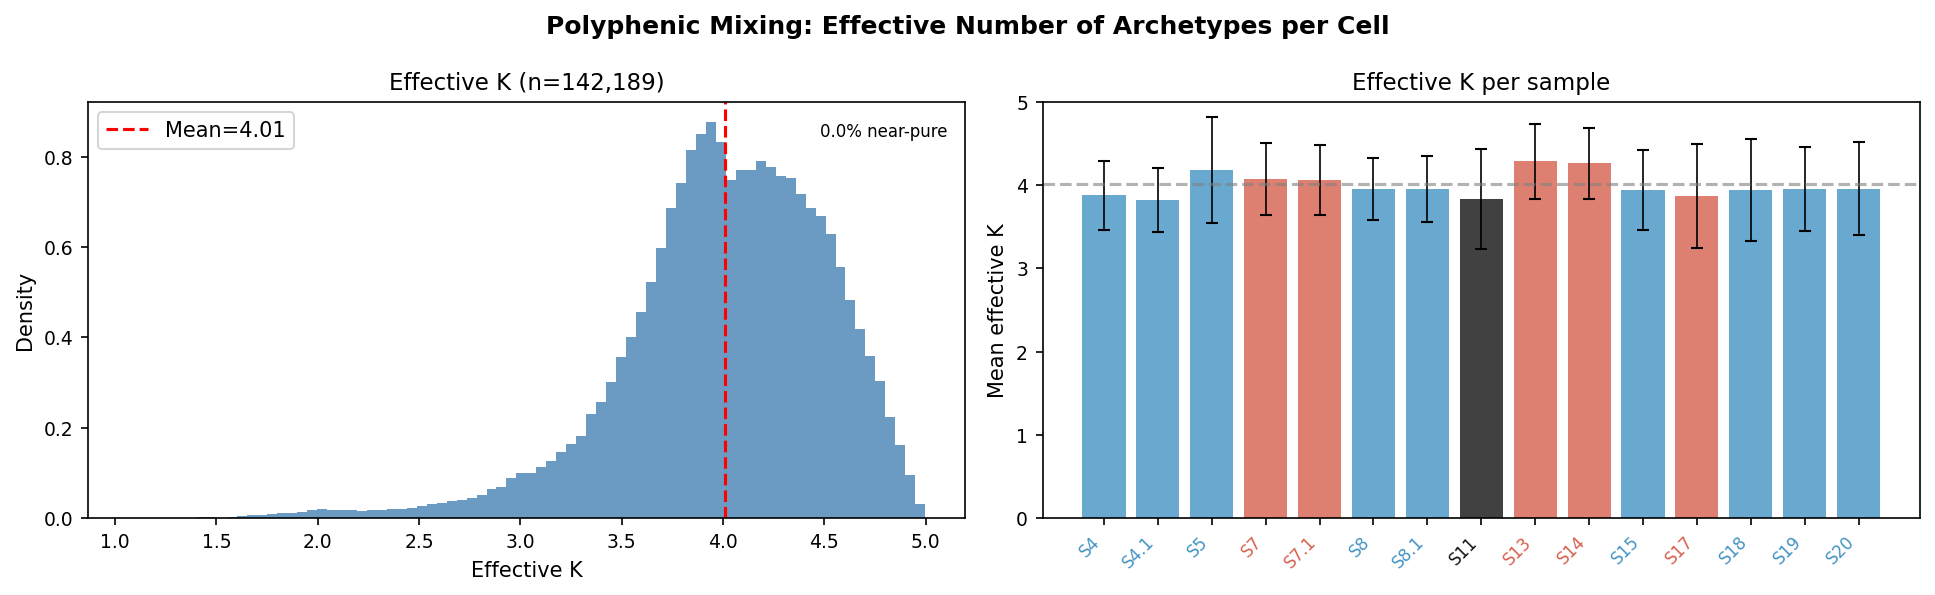

Mean eff_k=4.010  Polyphenic: 100.0%


In [8]:
# Figure 6: Effective K
W = all_w[W_COLS].values.astype(float)
eff_k = np.exp(-np.sum(W * np.log(W + 1e-12), axis=1)); all_w['eff_k'] = eff_k
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(eff_k, bins=80, color='steelblue', alpha=0.8, density=True)
axes[0].axvline(eff_k.mean(), color='red', ls='--', label=f'Mean={eff_k.mean():.2f}')
axes[0].set_xlabel('Effective K'); axes[0].set_ylabel('Density'); axes[0].set_title(f'Effective K (n={len(eff_k):,})'); axes[0].legend()
axes[0].text(0.98, 0.95, f'{(eff_k<1.5).mean()*100:.1f}% near-pure', transform=axes[0].transAxes, ha='right', va='top', fontsize=8)
eff_means = [all_w.loc[all_w['sample_id']==s,'eff_k'].mean() for s in sample_order]
eff_stds  = [all_w.loc[all_w['sample_id']==s,'eff_k'].std() for s in sample_order]
bar_colors = [SUBTYPE_COLORS.get(CLINICAL.get(str(s),{}).get('subtype','?'),'gray') for s in sample_order]
axes[1].bar(range(len(sample_order)), eff_means, yerr=eff_stds, capsize=3, color=bar_colors, alpha=0.8, ecolor='black', error_kw={'lw':0.8})
axes[1].axhline(eff_k.mean(), color='gray', ls='--', alpha=0.6)
axes[1].set_xticks(range(len(sample_order))); axes[1].set_xticklabels([f'S{s}' for s in sample_order], rotation=45, ha='right', fontsize=8)
for tick, sid in zip(axes[1].get_xticklabels(), sample_order):
    tick.set_color(SUBTYPE_COLORS.get(CLINICAL.get(str(sid),{}).get('subtype','?'),'black'))
axes[1].set_ylabel('Mean effective K'); axes[1].set_ylim(0, K); axes[1].set_title('Effective K per sample')
fig.suptitle('Polyphenic Mixing: Effective Number of Archetypes per Cell', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig6_effective_k.png'); fig.savefig(FIG_DIR / 'fig6_effective_k.pdf')
plt.show(); print(f'Mean eff_k={eff_k.mean():.3f}  Polyphenic: {(eff_k>=1.5).mean()*100:.1f}%')

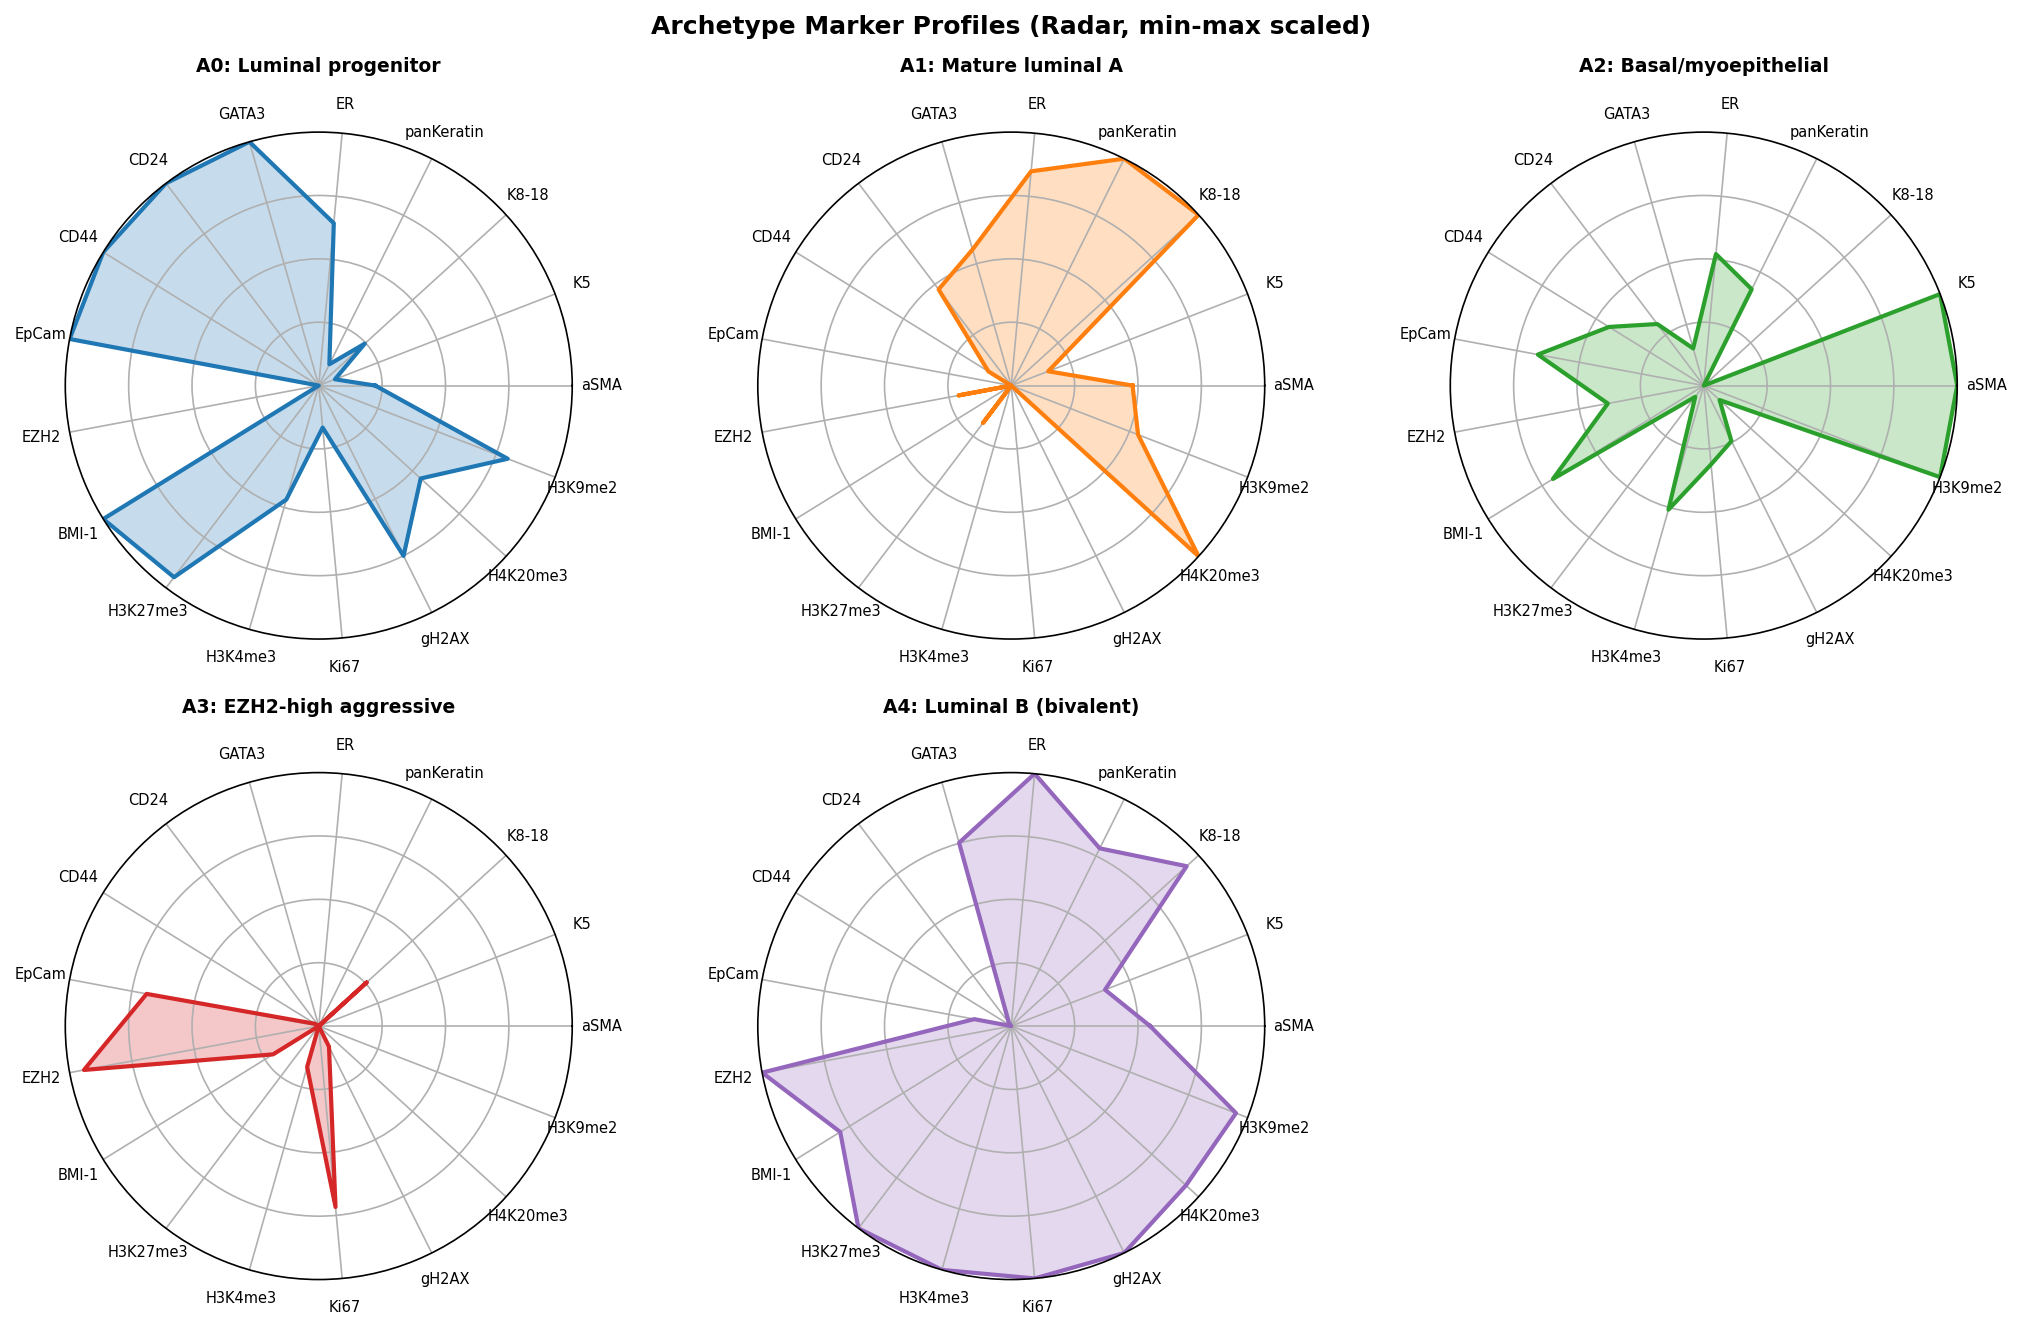

Saved fig7


In [9]:
# Figure 7: Radar profiles
radar_markers = [m for m in ['aSMA','K5','K8-18','panKeratin','ER','GATA3','CD24','CD44',
                 'EpCam','EZH2','BMI-1','H3K27me3','H3K4me3','Ki67','gH2AX','H4K20me3','H3K9me2'] if m in MARKERS]
N = len(radar_markers)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist(); angles += angles[:1]
fig, axes = plt.subplots(2, 3, figsize=(14, 9), subplot_kw=dict(polar=True)); axes = axes.flatten()
cm_r = cm[radar_markers].copy()
cm_sc = (cm_r - cm_r.min(axis=0)) / (cm_r.max(axis=0) - cm_r.min(axis=0) + 1e-6)
for i, (comp, color) in enumerate(zip(COMP_NAMES, ARCHETYPE_COLORS)):
    ax = axes[i]; vals = cm_sc.loc[comp].values.tolist(); vals += vals[:1]
    ax.plot(angles, vals, color=color, lw=2); ax.fill(angles, vals, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_markers, size=7)
    ax.set_ylim(0, 1); ax.set_yticks([0.25,0.5,0.75]); ax.set_yticklabels([])
    ax.set_title(comp, size=9, fontweight='bold', pad=12)
axes[-1].set_visible(False)
fig.suptitle('Archetype Marker Profiles (Radar, min-max scaled)', fontsize=12, fontweight='bold')
plt.tight_layout(); fig.savefig(FIG_DIR / 'fig7_radar_profiles.png'); fig.savefig(FIG_DIR / 'fig7_radar_profiles.pdf')
plt.show(); print('Saved fig7')

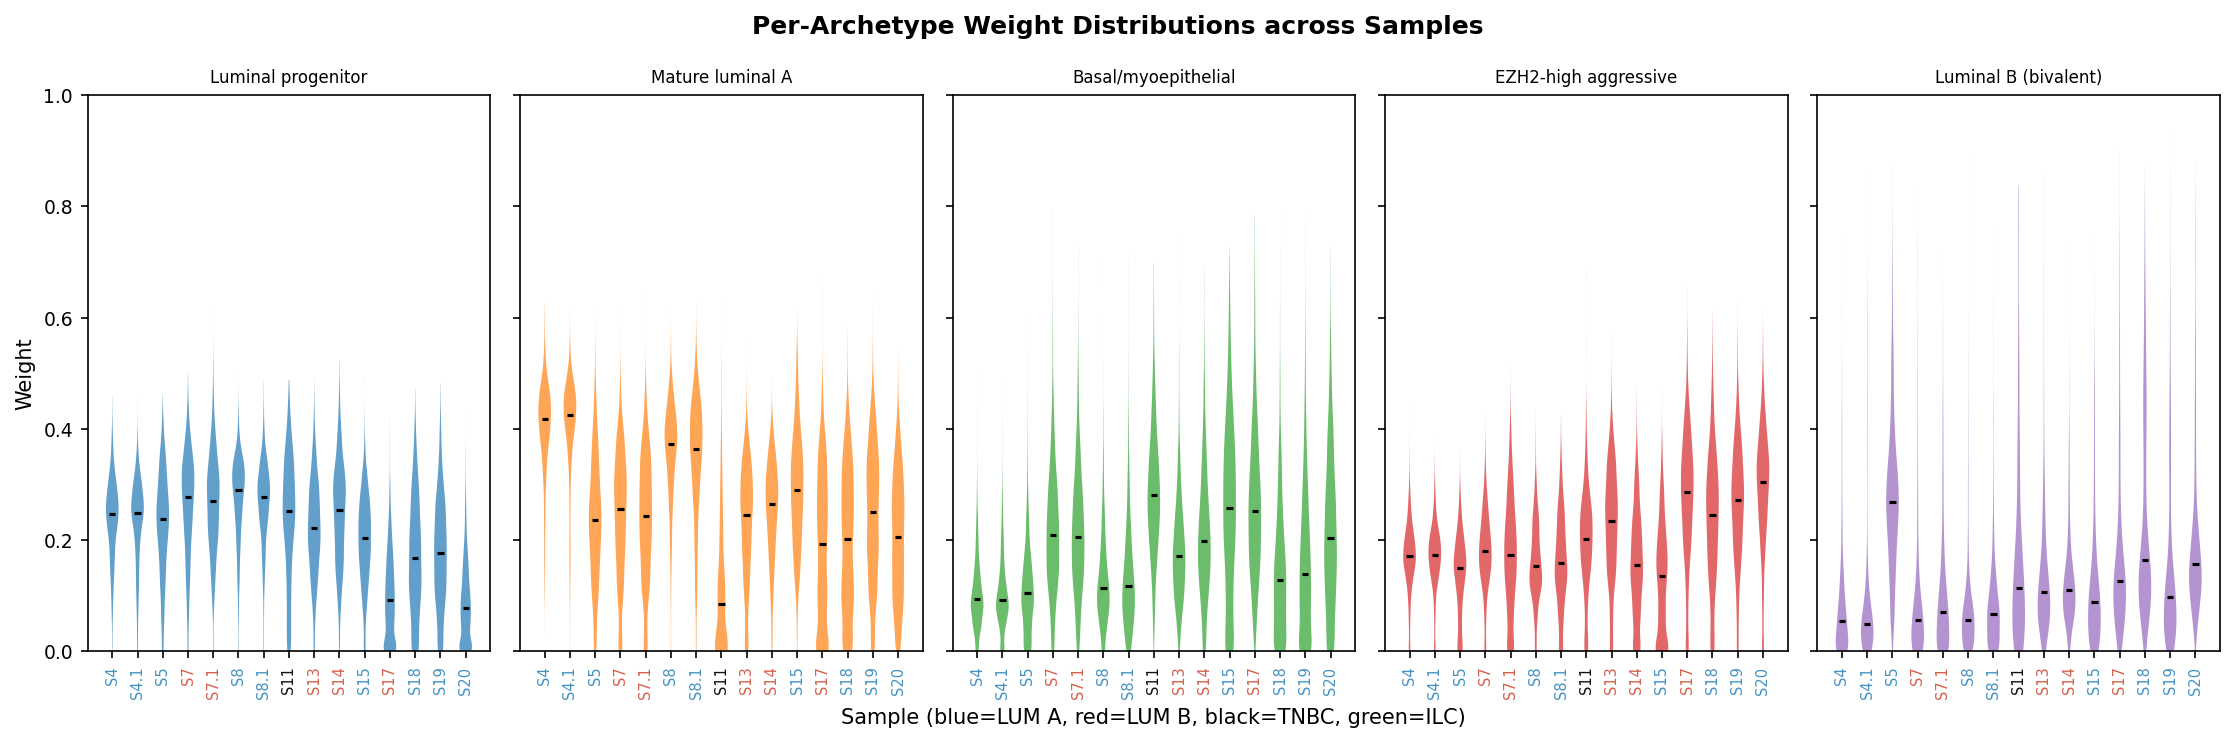

Saved fig8


In [10]:
# Figure 8: Weight distributions violin
fig, axes = plt.subplots(1, K, figsize=(15, 5), sharey=True)
for i, (comp, color) in enumerate(zip(COMP_NAMES, ARCHETYPE_COLORS)):
    plot_data = [all_w.loc[all_w['sample_id']==s, f'w_{i}'].values for s in sample_order]
    parts = axes[i].violinplot(plot_data, positions=range(len(sample_order)), showmedians=True, showextrema=False)
    for pc in parts['bodies']: pc.set_facecolor(color); pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    axes[i].set_xticks(range(len(sample_order))); axes[i].set_xticklabels([f'S{s}' for s in sample_order], rotation=90, fontsize=7)
    for tick, sid in zip(axes[i].get_xticklabels(), sample_order):
        tick.set_color(SUBTYPE_COLORS.get(CLINICAL.get(str(sid),{}).get('subtype','?'),'black'))
    axes[i].set_title(comp.split(': ')[1], fontsize=8); axes[i].set_ylim(0, 1)
    if i == 0: axes[i].set_ylabel('Weight')
axes[K//2].set_xlabel('Sample (blue=LUM A, red=LUM B, black=TNBC, green=ILC)')
fig.suptitle('Per-Archetype Weight Distributions across Samples', fontweight='bold')
plt.tight_layout(); fig.savefig(FIG_DIR / 'fig8_weight_distributions.png'); fig.savefig(FIG_DIR / 'fig8_weight_distributions.pdf')
plt.show(); print('Saved fig8')

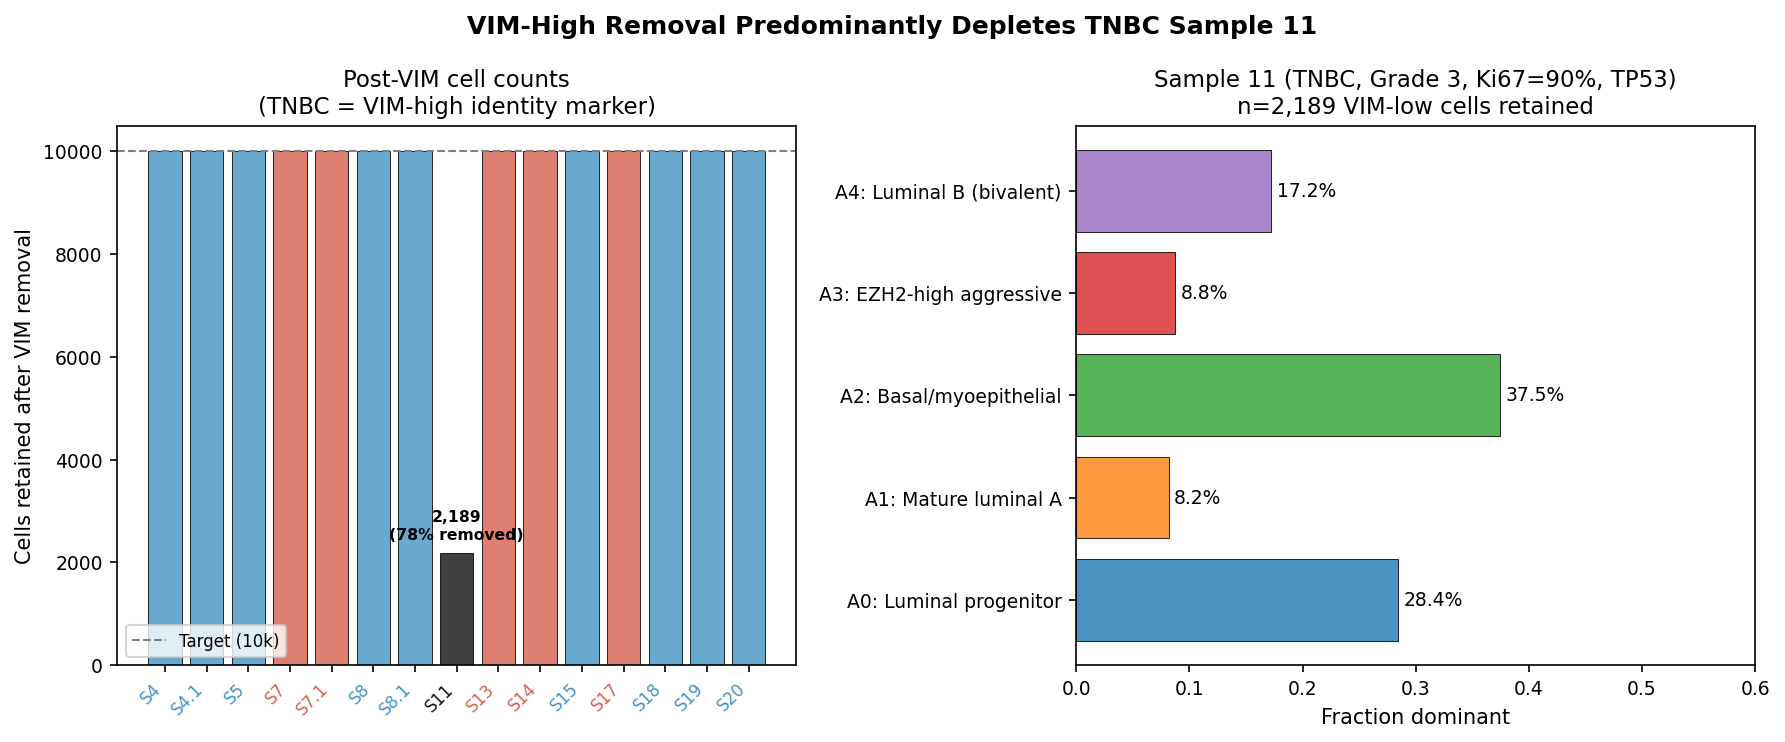

Saved fig9


In [11]:
# Figure 9: VIM removal impact - TNBC sample 11
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = [sample_counts.get(s, 0) for s in sample_order]
bar_colors = [SUBTYPE_COLORS.get(CLINICAL.get(str(s),{}).get('subtype','?'),'gray') for s in sample_order]
bars = axes[0].bar(range(len(sample_order)), counts, color=bar_colors, alpha=0.8, edgecolor='black', lw=0.5)
axes[0].axhline(10000, color='gray', ls='--', lw=1, label='Target (10k)')
axes[0].set_xticks(range(len(sample_order))); axes[0].set_xticklabels([f'S{s}' for s in sample_order], rotation=45, ha='right', fontsize=8)
for tick, sid in zip(axes[0].get_xticklabels(), sample_order):
    tick.set_color(SUBTYPE_COLORS.get(CLINICAL.get(str(sid),{}).get('subtype','?'),'black'))
for bar, sid in zip(bars, sample_order):
    if str(sid) == '11':
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                     f'{int(bar.get_height()):,}\n(78% removed)', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
axes[0].set_ylabel('Cells retained after VIM removal')
axes[0].set_title('Post-VIM cell counts\n(TNBC = VIM-high identity marker)'); axes[0].legend(fontsize=8)
s11_dom = per_sample_dom.loc['11'] if '11' in per_sample_dom.index else pd.Series(dtype=float)
vals_dom = s11_dom.reindex(COMP_NAMES, fill_value=0).values
axes[1].barh(COMP_NAMES, vals_dom, color=ARCHETYPE_COLORS, alpha=0.8, edgecolor='black', lw=0.5)
for i, v in enumerate(vals_dom): axes[1].text(v+0.005, i, f'{v:.1%}', va='center', fontsize=9)
axes[1].set_xlabel('Fraction dominant')
axes[1].set_title('Sample 11 (TNBC, Grade 3, Ki67=90%, TP53)\nn=2,189 VIM-low cells retained'); axes[1].set_xlim(0, 0.6)
fig.suptitle('VIM-High Removal Predominantly Depletes TNBC Sample 11', fontweight='bold')
plt.tight_layout(); fig.savefig(FIG_DIR / 'fig9_vim_impact_tnbc.png'); fig.savefig(FIG_DIR / 'fig9_vim_impact_tnbc.pdf')
plt.show(); print('Saved fig9')

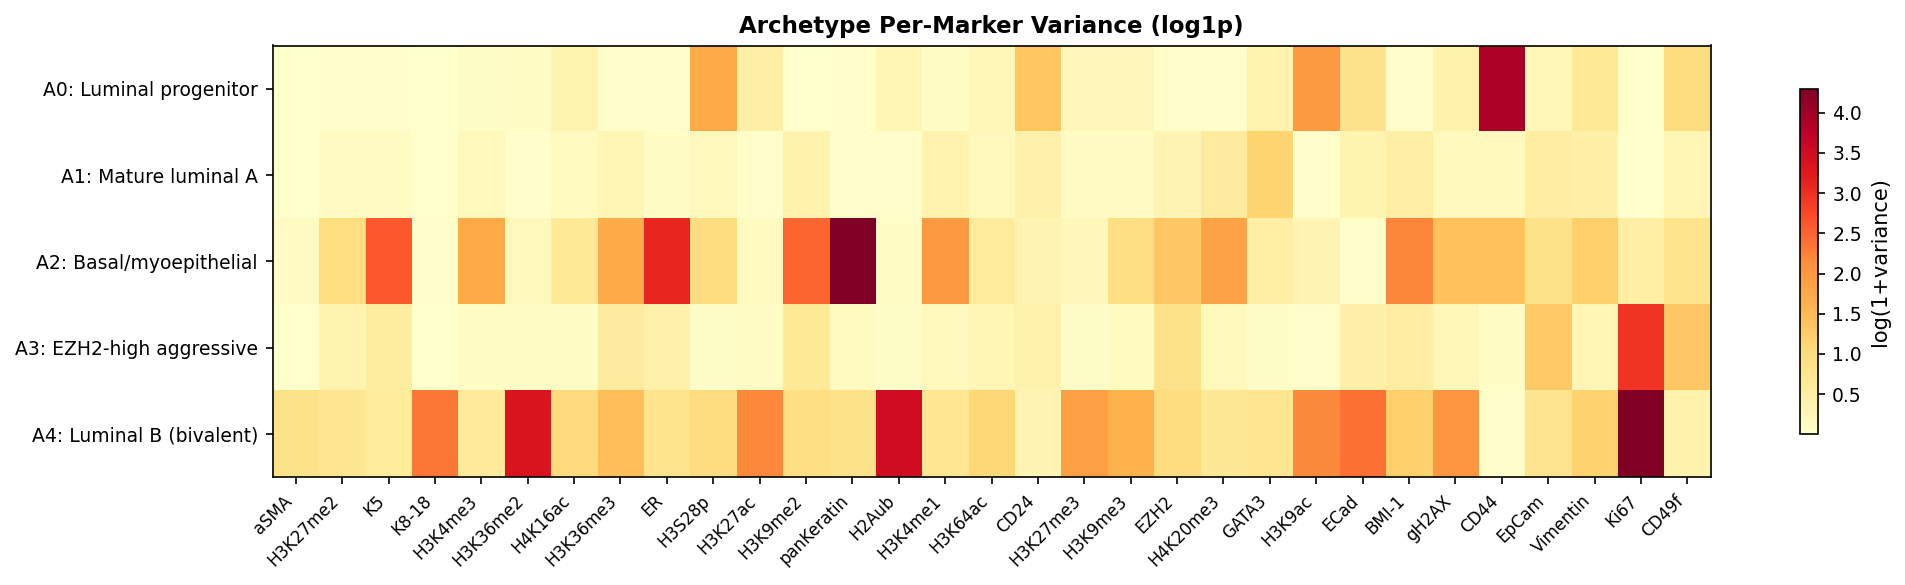

Mean variance: A0: Luminal progenitor      2.2292
A1: Mature luminal A        0.3051
A2: Basal/myoepithelial     5.3751
A3: EZH2-high aggressive    1.0399
A4: Luminal B (bivalent)    6.8008


In [12]:
# Figure 10: Archetype variance
marker_order_v = cm.abs().max(axis=0).sort_values(ascending=False).index.tolist()
cv_ord = cv[marker_order_v]
fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(np.log1p(cv_ord.values), aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(marker_order_v))); ax.set_xticklabels(marker_order_v, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(K)); ax.set_yticklabels(COMP_NAMES, fontsize=9)
ax.set_title('Archetype Per-Marker Variance (log1p)', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='log(1+variance)', shrink=0.8)
plt.tight_layout(); fig.savefig(FIG_DIR / 'fig10_archetype_variance.png'); fig.savefig(FIG_DIR / 'fig10_archetype_variance.pdf')
plt.show(); print('Mean variance:', cv.mean(axis=1).round(4).to_string())

In [13]:
# Generate markdown + PDF report
import subprocess

W_all = all_w[W_COLS].values.astype(float)
eff_k_all = np.exp(-np.sum(W_all * np.log(W_all + 1e-12), axis=1))
mean_eff_k = eff_k_all.mean()
frac_poly   = (eff_k_all >= 1.5).mean()
frac_pure   = (eff_k_all < 1.5).mean()
best_val    = hist['val_loss'].min()
best_ep     = int(hist['val_loss'].idxmin())
n_cells     = adata.shape[0]
n_markers   = adata.shape[1]
dom_fracs   = [(all_w['dominant']==i).mean() for i in range(K)]

# Per-sample table
table_rows = []
for sid in sample_order:
    c    = CLINICAL.get(str(sid), {})
    sub  = c.get('subtype','?')
    g    = c.get('grade','?')
    ki   = c.get('ki67',0)
    er   = c.get('er',0)
    note = c.get('note','')
    tt   = c.get('tumor_type','IDC')
    nc   = int(sample_counts.get(sid, 0))
    row  = per_sample_dom.loc[sid] if sid in per_sample_dom.index else pd.Series(dtype=float)
    da   = row.idxmax() if not row.empty else '?'
    df_  = row.max()   if not row.empty else 0
    flag = ' **TNBC**' if sub=='TN' else (' ILC' if tt=='ILC' else '')
    if 'replicate' in note: flag += ' *(rep.)*'
    mut  = note if 'replicate' not in note else ''
    table_rows.append(
        f'| S{sid}{flag} | {sub} G{g} | {ki:.0%} | {er:.0%} | {nc:,} | {da} | {df_:.0%} | {mut} |'
    )
table_str = '\n'.join(table_rows)

lines = []
lines.append('---')
lines.append('title: "Probabilistic Archetypal Decomposition of VIM-Filtered Breast CyTOF Data (K=5)"')
lines.append('author: "Guy Ron"')
lines.append('date: "April 2026"')
lines.append('geometry: margin=2.5cm')
lines.append('fontsize: 10pt')
lines.append('linestretch: 1.15')
lines.append('header-includes: |')
lines.append(r'  \usepackage{booktabs}')
lines.append(r'  \usepackage{amsmath}')
lines.append(r'  \usepackage{amssymb}')
lines.append(r'  \usepackage{graphicx}')
lines.append(r'  \usepackage{float}')
lines.append(r'  \usepackage{caption}')
lines.append(r'  \usepackage{microtype}')
lines.append(r'  \captionsetup{font=small, labelfont=bf}')
lines.append('---')
lines.append('')
lines.append('# Abstract')
lines.append('')
lines.append(
    f'We apply a Probabilistic Archetypal Autoencoder (PAE) to a breast tumour mass cytometry '
    f'dataset of {n_markers} markers across 15 patient samples after removing VIM-high cells. '
    f'The cohort comprises 10 ER-positive tumours (LUM A/B), 1 triple-negative IDC '
    f'(sample 11, Grade 3, Ki67=90%, TP53-mutant), and 1 invasive lobular carcinoma (ILC, sample 8). '
    f'At K=5, five cell-state programmes are identified: mature luminal A (A1, {dom_fracs[1]:.1%}), '
    f'luminal progenitor (A0, {dom_fracs[0]:.1%}), VIM-low basal/myoepithelial residual (A2, {dom_fracs[2]:.1%}), '
    f'EZH2-high aggressive progenitor (A3, {dom_fracs[3]:.1%}), and Luminal B bivalent chromatin (A4, {dom_fracs[4]:.1%}). '
    f'Mean effective K={mean_eff_k:.2f}. VIM removal depletes 78% of cells from TNBC sample 11, '
    f'revealing that VIM-high identity is a core feature of the TNBC phenotype.'
)
lines.append('')
lines.append('# Introduction')
lines.append('')
lines.append(
    "Breast cancer encompasses Luminal A, Luminal B, HER2-enriched, and triple-negative subtypes "
    "with distinct prognosis and treatment sensitivity. Mass cytometry (CyTOF) quantifies 30--50 "
    "proteins per cell simultaneously. This cohort's panel combines surface identity markers "
    "(EpCam, CD24, CD44, aSMA, K5, K8/K18), lineage transcription factors (ER, GATA3), "
    "epigenetic regulators (EZH2, BMI-1), and 16 histone modifications. "
    "Vimentin (VIM) is expressed by mesenchymal cells, CAFs, and TNBC/basal-like tumour cells. "
    "We removed VIM-high cells to focus on VIM-low epithelial populations, noting that "
    "TNBC cells may be preferentially depleted."
)
lines.append('')
lines.append('# Methods')
lines.append('')
lines.append('## Probabilistic Archetypal Autoencoder (PAE)')
lines.append('')
lines.append(r'The encoder maps each cell to a weight vector $\mathbf{w}_i \in \Delta^{K-1}$:')
lines.append('')
lines.append(r'$$\mathbf{w}_i = \text{softmax}(f_\phi(\mathbf{x}_i)), \quad \sum_k w_{ik}=1, \quad w_{ik}\geq 0$$')
lines.append('')
lines.append(r'Reconstruction: $\hat{\mathbf{x}}_i = \sum_k w_{ik}\boldsymbol{\mu}_k$. Total loss:')
lines.append('')
lines.append(r'$$\mathcal{L} = \mathcal{L}_\text{NLL} + \lambda_e\mathcal{R}_e + \lambda_d\mathcal{R}_d + \lambda_v\mathcal{R}_v$$')
lines.append('')
lines.append(
    r'Entropy regularisation $\mathcal{R}_e = -\frac{1}{N}\sum_i H(\mathbf{w}_i)$, '
    r'diversity $\mathcal{R}_d$ penalises co-linear means, '
    r'variance $\mathcal{R}_v = \frac{1}{KM}\sum_{k,m}\exp(\sigma^2_{km})$. '
    r'Hyperparameters: $\lambda_e=10^{-3}$, $\lambda_d=5\times10^{-3}$, $\lambda_v=10^{-4}$.'
)
lines.append('')
lines.append('## Data Preprocessing')
lines.append('')
lines.append('Five sequential steps: (1) load all cells (~1.1M total); (2) clip markers to $[0, p_{99.9}]$;')
lines.append(r'(3) VIM-high removal via two-component GMM ($n_\text{init}=5$, full covariance);')
lines.append(r'(4) balanced downsampling to $\lfloor 300{,}000/S\rfloor$ cells per sample post-filtering;')
lines.append(r'(5) equal-sample z-scoring: $z_{im} = (x_{im}-\bar{\mu}_m)/\bar{\sigma}_m$, $\pi_s=1/S$.')
lines.append('')
lines.append('## Model Training')
lines.append('')
lines.append(
    f'Encoder: two FC hidden layers (128, 64), ReLU, dropout p=0.1. '
    f'AdamW (lr=1e-3, wd=1e-4, batch=8192), early stopping patience 15 on validation NLL. '
    f'K=5 seed 123 selected: best val NLL={best_val:.4f} at epoch {best_ep}.'
)
lines.append('')
lines.append('# Results')
lines.append('')
lines.append('## Cohort Clinical Summary')
lines.append('')
lines.append(
    'The cohort contains 12 distinct patient tumours (15 CyTOF samples including replicates): '
    '5 LUM A IDC (grades 2), 3 LUM B IDC (grade 3), 1 LUM A ILC (grade 2, CDH1-mutant, S8), '
    '1 TNBC IDC (grade 3, Ki67=90%, TP53-mutant, **S11**), '
    'and 1 high-grade LUM B with BRCA1 mutation (S13). '
    'PIK3CA H1047R: samples 8, 15, 19, 20. TP53 mutations: samples 11, 13, 14, 17. BRCA1: sample 13.'
)
lines.append('')
lines.append('## Five Archetypes Define the VIM-Low Compartment')
lines.append('')
lines.append(
    f'All five archetypes robustly active (mean usage 0.14--0.30). '
    f'Mean effective K={mean_eff_k:.2f} ({frac_poly:.1%} polyphenic; Figure 6).'
)
lines.append('')
lines.append('**A0: Luminal progenitor with active chromatin.**')
lines.append(
    'CD24 (+3.09 z), GATA3 (+2.60 z), EpCam (+1.78 z) with absent K8/K18 (--2.04 z) and '
    'pan-Keratin (--2.38 z). Elevated H3S28p (+3.54 z; mitosis), H3K36me3 (+3.41 z; transcription '
    'elongation), H3K64ac (+3.11 z). BMI-1 (+2.18 z) + H3K27me3 (+2.57 z) + H3K9me3 (+2.82 z) '
    'reflects bivalent Polycomb repression -- stem/progenitor hallmark. EZH2 (--2.24 z) depleted.'
)
lines.append('')
lines.append('**A1: Mature luminal A.**')
lines.append(
    'K8/K18 (+3.90 z), pan-Keratin (+3.28 z), ER (+1.48 z). H4K20me3 (+2.32 z): terminal '
    'differentiation heterochromatin. All active marks suppressed. BMI-1/EZH2 depleted. '
    'ILC samples (8, 8.1) 68--73% A1-dominant, consistent with ILC quiescence.'
)
lines.append('')
lines.append('**A2: Basal/myoepithelial (VIM-low residual).**')
lines.append(
    'aSMA (+5.79 z), K5 (+4.23 z), absent K8/K18 (--3.97 z), ECad (--1.71 z), GATA3 (--1.80 z). '
    'Vimentin near zero (--0.04 z): these cells survived VIM filtering. '
    'H3K9me2 (+1.99 z): constitutive heterochromatin of lineage-committed myoepithelium.'
)
lines.append('')
lines.append('**A3: EZH2-high aggressive progenitor.**')
lines.append(
    'EZH2 (+2.38 z), Ki67 (+0.80 z), ER (--3.54 z), aSMA (--4.46 z). '
    'Dominant in LUM B Grade 3 sample 17 (Ki67=80%, TP53+PIK3CA) and in LUM A samples 19--20 '
    '(PIK3CA H1047R), suggesting PIK3CA-AKT-driven EZH2 stabilisation.'
)
lines.append('')
lines.append('**A4: Luminal B with bivalent chromatin.**')
lines.append(
    'Co-elevation of active (H3K4me3 +3.81 z, H3K36me2 +3.78 z, H4K16ac +3.58 z, H3K27ac +3.40 z) '
    'and repressive (H3K27me2 +4.42 z, H3K9me3 +2.65 z, BMI-1 +1.30 z, EZH2 +2.67 z) marks. '
    'K8/K18 (+3.40 z), ER (+2.38 z). gH2AX (+2.17 z): replication stress/DNA damage.'
)
lines.append('')
lines.append('## Per-Sample Tumour Taxonomy')
lines.append('')
lines.append('| Sample | Subtype/Grade | Ki67 | ER | Cells | Dominant archetype | Fraction | Notes |')
lines.append('|--------|--------------|------|----|-------|-------------------|----------|-------|')
lines.append(table_str)
lines.append('')
lines.append('*Table 1. Clinical annotation and archetype composition. Cells = post-VIM count.*')
lines.append('')
lines.append('## Sample 11 (TNBC): VIM-High Identity Depletes 78% of Cells')
lines.append('')
lines.append(
    'Sample 11 is the sole TNBC: Grade 3 IDC, Ki67=90%, ER=5%, TP53 c.375+1delG (66% VAF). '
    'After VIM removal, 2,189 cells remain (~78% depleted). This is a biological finding: '
    'TNBC/basal-like tumour cells constitutively express Vimentin as part of their '
    'mesenchymal identity (co-expressed with K5, aSMA, CD44). VIM filtering removes the core TNBC tumour cells. '
    'Among retained VIM-low cells, S11 is A2-dominant (38%, K5+/aSMA+) with A3 co-enrichment '
    '(29%, EZH2-high/Ki67+) -- consistent with residual VIM-low basal-like cancer cells or '
    'tumour-margin myoepithelium. This highlights a key limitation: VIM-based filtering '
    'is not appropriate for TNBC-containing cohorts.'
)
lines.append('')
lines.append('## Sample 13 (LUM B, BRCA1-mutant): Luminal/Progenitor Plasticity')
lines.append('')
lines.append(
    'Sample 13: Grade 3 LUM B IDC, ER=77%, Ki67=50%, PR=weak, TP53 p.Q331H (40%), '
    'PIK3CA p.E545K (64%), BRCA1 p.R1203* (36%); pathological basal-like content 47%. '
    'PAE: A1-dominant (31%, mature luminal) with A3 co-enrichment (29%, EZH2-high). '
    'This reflects BRCA1-associated luminal plasticity: BRCA1 haploinsufficiency '
    'disrupts luminal differentiation, enabling co-expression of luminal markers '
    'alongside progenitor/basal programmes. Unlike TNBC, S13 retains 10,000 cells '
    'post-VIM filtering, confirming its basal-like cells are VIM-low (K5+/ER+ without EMT).'
)
lines.append('')
lines.append('## PIK3CA-EZH2 Axis: Epigenetic Aggressiveness in LUM A')
lines.append('')
lines.append(
    'Samples 19 and 20 (LUM A Grade 2, Ki67=20%) are 30% and 44% A3-dominant respectively, '
    'despite low clinical proliferation. Both carry PIK3CA H1047R -- the most oncogenic PIK3CA '
    'variant -- which activates AKT-mediated EZH2 phosphorylation and stabilisation. '
    'The PAE detects a subpopulation-level EZH2-high epigenetic state invisible to bulk Ki67, '
    'suggesting occult aggressive potential in these clinically low-risk LUM A tumours.'
)
lines.append('')
lines.append('## Polyphenic Mixing')
lines.append('')
lines.append(
    f'Mean effective K={mean_eff_k:.2f}; {frac_poly:.1%} polyphenic. '
    'A1 (mature luminal) and A3 (EZH2-high) are anti-correlated, confirming '
    'mutual exclusivity of terminal differentiation and dedifferentiation (Figure 5).'
)
lines.append('')
lines.append('# Discussion')
lines.append('')
lines.append(
    'Three key findings: (1) **VIM as TNBC identity marker** -- VIM filtering is '
    'inappropriate for TNBC-containing cohorts; the depletion of S11 is diagnostic. '
    '(2) **PIK3CA-EZH2 axis** -- PIK3CA H1047R drives EZH2-high epigenetic state in '
    'LUM A tumours (S19, S20) that is not reflected in Ki67, suggesting subpopulation-level '
    'aggressiveness requiring EZH2 inhibitor investigation. '
    '(3) **BRCA1 luminal plasticity** -- S13\'s A1/A3 co-enrichment reflects BRCA1-associated '
    'disruption of luminal differentiation commitment, a targetable vulnerability '
    'distinct from BRCA1-associated TNBC.'
)
lines.append('')
lines.append('# Figures')
lines.append('')
lines.append('![**Figure 1.** Archetype marker profiles (z-score heatmap).](figures/fig1_archetype_heatmap.png){width=100%}')
lines.append('')
lines.append(f'![**Figure 2.** Training convergence (best val NLL={best_val:.4f} at epoch {best_ep}).](figures/fig2_training_convergence.png){{width=100%}}')
lines.append('')
lines.append('![**Figure 3.** Per-sample archetype composition with clinical subtype annotations.](figures/fig3_sample_composition.png){width=100%}')
lines.append('')
lines.append('![**Figure 4.** Clinical heatmap and Ki67 vs EZH2-high archetype enrichment.](figures/fig4_clinical_heatmap.png){width=100%}')
lines.append('')
lines.append('![**Figure 5.** Pairwise archetype weight relationships.](figures/fig5_weight_correlations.png){width=100%}')
lines.append('')
lines.append(f'![**Figure 6.** Effective K distribution (mean={mean_eff_k:.2f}).](figures/fig6_effective_k.png){{width=100%}}')
lines.append('')
lines.append('![**Figure 7.** Radar profiles per archetype (key identity + epigenomic markers).](figures/fig7_radar_profiles.png){width=100%}')
lines.append('')
lines.append('![**Figure 8.** Per-archetype weight distributions per sample (violin).](figures/fig8_weight_distributions.png){width=100%}')
lines.append('')
lines.append('![**Figure 9.** VIM removal: S11 (TNBC) depleted 78%. Right: S11 VIM-low cell composition.](figures/fig9_vim_impact_tnbc.png){width=100%}')
lines.append('')
lines.append('![**Figure 10.** Archetype per-marker variance (log1p).](figures/fig10_archetype_variance.png){width=100%}')

report = '\n'.join(lines)
report_path = OUT_DIR / 'report.md'
with open(report_path, 'w') as f:
    f.write(report)
print(f'Report written: {report_path}')

pdf_path = OUT_DIR / 'report.pdf'
result = subprocess.run(
    ['pandoc', str(report_path), '-o', str(pdf_path),
     '--pdf-engine=xelatex', f'--resource-path={str(OUT_DIR)}'],
    capture_output=True, text=True
)
if result.returncode == 0:
    print(f'PDF built: {pdf_path}')
else:
    print('PDF build failed:')
    print(result.stderr[:3000])


Report written: ../../reports/k5_novim_pae/report.md


PDF built: ../../reports/k5_novim_pae/report.pdf
